In [1]:
# https://www.kaggle.com/datasets/smid80/weatherww2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv("00_files/04_weather_ww2_ml_ready.csv")

In [4]:
df.head()

,MaxTemp,MinTemp,Precip,Snowfall,PRCP,SNF,ELEV,Latitude,Longitude,year,month,dayofyear,MeanTemp_lag1,MeanTemp_lag2,STA,STATE/COUNTRY ID,NAME,MeanTemp
0,26.111111,22.222222,2.54,0.0,0.1,0.0,62,5.6,-0.3,1942,7,184,25.555556,23.888889,10001,GH,ACCRA,24.444444
1,26.666667,22.222222,2.54,0.0,0.1,0.0,62,5.6,-0.3,1942,7,185,24.444444,25.555556,10001,GH,ACCRA,24.444444
2,26.666667,21.666667,0.00,0.0,0.0,0.0,62,5.6,-0.3,1942,7,186,24.444444,24.444444,10001,GH,ACCRA,24.444444
3,26.666667,21.666667,0.00,0.0,0.0,0.0,62,5.6,-0.3,1942,7,187,24.444444,24.444444,10001,GH,ACCRA,24.444444
4,28.333333,22.777778,0.00,0.0,0.0,0.0,62,5.6,-0.3,1942,7,188,24.444444,24.444444,10001,GH,ACCRA,25.555556


In [5]:
df.isna().sum()

MaxTemp             0
MinTemp             0
Precip              0
Snowfall            0
PRCP                0
SNF                 0
ELEV                0
Latitude            0
Longitude           0
year                0
month               0
dayofyear           0
MeanTemp_lag1       0
MeanTemp_lag2       0
STA                 0
STATE/COUNTRY ID    0
NAME                0
MeanTemp            0
dtype: int64

In [6]:
target_col = "MeanTemp"

numeric_features = [
    "MaxTemp", "MinTemp",      
    "Precip", "Snowfall", "PRCP", "SNF", 
    "ELEV", "Latitude", "Longitude",
    "year", "month", "dayofyear",
    "MeanTemp_lag1", "MeanTemp_lag2",
]

categorical_features = [
    "STA",  
    "STATE/COUNTRY ID",
    "NAME",
]

In [7]:
y = df[target_col]
X = df[numeric_features + categorical_features]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [10]:
X_train[numeric_features].corr()

,MaxTemp,MinTemp,Precip,Snowfall,PRCP,SNF,ELEV,Latitude,Longitude,year,month,dayofyear,MeanTemp_lag1,MeanTemp_lag2
MaxTemp,1.000000,0.866407,-0.000983,-0.361913,-0.000983,-0.361913,0.038381,-0.531905,0.043602,0.012000,0.031202,0.029763,0.943310,0.928601
MinTemp,0.866407,1.000000,0.091149,-0.336031,0.091149,-0.336031,0.057704,-0.587787,-0.093888,-0.045621,0.071983,0.070502,0.952641,0.939517
Precip,-0.000983,0.091149,1.000000,-0.011881,1.000000,-0.011881,0.084151,-0.104441,0.008490,0.003448,0.040736,0.040609,0.068011,0.070412
Snowfall,-0.361913,-0.336031,-0.011881,1.000000,-0.011881,1.000000,-0.020031,0.218688,-0.030986,-0.002428,-0.046247,-0.045831,-0.361903,-0.362000
PRCP,-0.000983,0.091149,1.000000,-0.011881,1.000000,-0.011881,0.084151,-0.104441,0.008490,0.003448,0.040736,0.040609,0.068011,0.070412
SNF,-0.361913,-0.336031,-0.011881,1.000000,-0.011881,1.000000,-0.020031,0.218688,-0.030986,-0.002428,-0.046247,-0.045831,-0.361903,-0.362000
ELEV,0.038381,0.057704,0.084151,-0.020031,0.084151,-0.020031,1.000000,-0.066744,0.000459,0.042709,0.008089,0.008332,0.049650,0.049450
Latitude,-0.531905,-0.587787,-0.104441,0.218688,-0.104441,0.218688,-0.066744,1.000000,-0.124277,0.026670,0.008905,0.008875,-0.578684,-0.578901
Longitude,0.043602,-0.093888,0.008490,-0.030986,0.008490,-0.030986,0.000459,-0.124277,1.000000,0.243900,-0.005153,-0.004569,-0.025452,-0.025107
year,0.012000,-0.045621,0.003448,-0.002428,0.003448,-0.002428,0.042709,0.026670,0.243900,1.000000,-0.140616,-0.140705,-0.017340,-0.017885


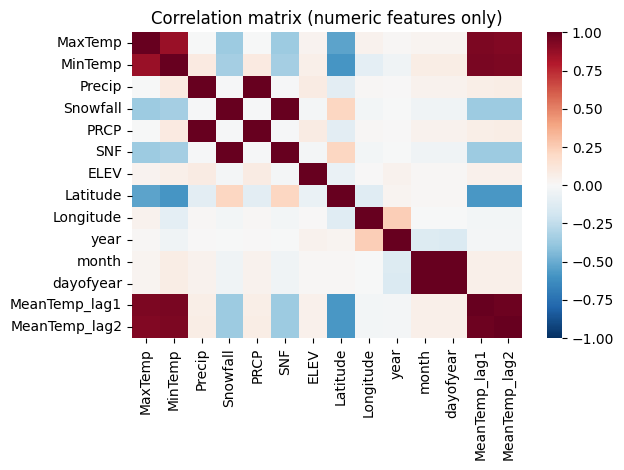

In [11]:
sns.heatmap(X_train[numeric_features].corr(), annot=False, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (numeric features only)")
plt.tight_layout()
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [13]:
# scale numeric features, one-hot encode categoricals (StandardScaler cannot handle strings like 'LC')
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

In [14]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
regression = LinearRegression()

In [17]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
df.iloc[0]

MaxTemp             26.111111
MinTemp             22.222222
Precip                   2.54
Snowfall                  0.0
PRCP                      0.1
SNF                       0.0
ELEV                       62
Latitude                  5.6
Longitude                -0.3
year                     1942
month                       7
dayofyear                 184
MeanTemp_lag1       25.555556
MeanTemp_lag2       23.888889
STA                     10001
STATE/COUNTRY ID           GH
NAME                    ACCRA
MeanTemp            24.444444
Name: 0, dtype: object

In [19]:
y_pred = regression.predict(X_test)

In [20]:
y_pred

array([27.51545062, 11.12433842, 20.85572133, ..., 15.1571762 ,
       15.8257834 ,  8.34449817], shape=(28846,))

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
mse = mean_squared_error(y_test, y_pred) # average of squared errors (penalizes big mistakes more)
mae = mean_absolute_error(y_test, y_pred) # average of absolute differences between real and predicted values
rmse = np.sqrt(mse) # square root of MSE (error in same unit as target)
r2score = r2_score(y_test, y_pred) # measures how well the model explains the variance (goodness of fit)
r2adjustedscore = 1 - (1-r2score) * (len(y_test) -1) / (len(y_test) - X_test.shape[1] -1) # adjusted r2 score

print("mse : ", mse)
print("mae : ", mae)
print("rmse : ", rmse)
print("r2 score : ", r2score)
print("r2 adjusted score :", r2adjustedscore) 

mse :  0.056551339217186115
mae :  0.15188907236266996
rmse :  0.23780525481407283
r2 score :  0.999011645035
r2 adjusted score : 0.9989980987887743
